# 📡 Telecom X Parte 2 — Predicción de Churn (Cancelación de Clientes)

**Estructura del notebook:**
1. Carga y exploración inicial
2. Preparación de los datos
3. Correlación y selección de variables
4. Modelado predictivo
5. Interpretación y conclusiones

---
## 1. 📦 Importación de Librerías y Carga de Datos

In [10]:
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


In [11]:
# Carga del dataset y normalización

df_raw = pd.read_csv('datos_tratados.csv')

for col in ['customer', 'phone', 'internet', 'account']:
    df_raw[col] = df_raw[col].apply(ast.literal_eval)

df = pd.concat([
    df_raw[['customerID', 'Churn']],
    pd.json_normalize(df_raw['customer']),
    pd.json_normalize(df_raw['phone']),
    pd.json_normalize(df_raw['internet']),
    pd.json_normalize(df_raw['account'])
], axis=1)

# Charges.Total viene como string; se convierte a numérico
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

print(f'Forma del dataset: {df.shape}')
df.head(3)

Forma del dataset: (7267, 21)


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


In [12]:
# Exploración inicial

print('=== Tipos de datos ===')
print(df.dtypes)
print('\n=== Valores nulos ===')
print(df.isnull().sum())
print('\n=== Estadísticas numéricas ===')
df.describe()

=== Tipos de datos ===
customerID           object
Churn                object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
Charges.Monthly     float64
Charges.Total       float64
dtype: object

=== Valores nulos ===
customerID            0
Churn               224
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV     

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total
count,7267.000000,7267.000000,7267.000000,7256.000000
mean,0.162653,32.346498,64.720098,2280.634213
std,0.369074,24.571773,30.129572,2268.632997
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.425000,400.225000
50%,0.000000,29.000000,70.300000,1391.000000
75%,0.000000,55.000000,89.875000,3785.300000
max,1.000000,72.000000,118.750000,8684.800000


---
## 2. 🛠️ Preparación de los Datos

In [13]:
# Se eliminan columnas sin valor predictivo

df = df.drop(columns=['customerID'])
print(f'Columnas restantes: {df.shape[1]}')
print(df.columns.tolist())

Columnas restantes: 20
['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total']


In [14]:
# Se tratan los valores nulos (churn) ya que no suman importancia para el entrenamiento

df = df.dropna(subset=['Churn'])

df = df.assign(Churn=df['Churn'].map({'Yes': 1, 'No': 0}))

median_total = df['Charges.Total'].median()
df = df.assign(**{'Charges.Total': df['Charges.Total'].fillna(median_total)})

print(f'Registros tras limpieza: {len(df)}')
print(f'Nulos restantes:\n{df.isnull().sum()[df.isnull().sum() > 0]}')

Registros tras limpieza: 7043
Nulos restantes:
Series([], dtype: int64)


In [15]:
# Codificación de variables categóricas (One Hot Encoding)

cat_cols = [col for col in df.columns if df[col].dtype == object]
print(f'Columnas categóricas a codificar: {cat_cols}')

df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_enc['Churn'] = df_enc['Churn'].astype(int)

print(f'\nDimensiones tras encoding: {df_enc.shape}')
df_enc.head(3)

Columnas categóricas a codificar: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Dimensiones tras encoding: (7043, 31)


,Churn,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,9,65.6,593.30,False,True,True,True,False,...,False,True,False,False,True,False,True,False,False,True
1,0,0,9,59.9,542.40,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,1,0,4,73.9,280.85,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


Distribución de clases
  No cancelaron (0):  5174  (73.5%)
  Cancelaron    (1):  1869  (26.5%)


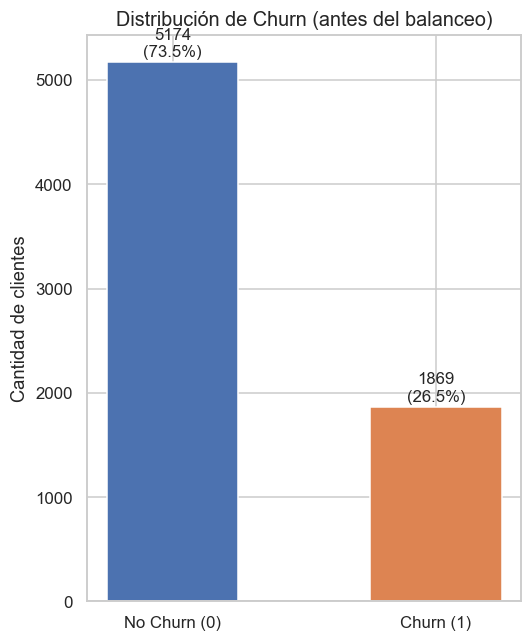


Existe un desbalance moderado (~73% vs ~27%).
Se aplicará oversampling para balancear las clases.


In [18]:
# Análisis de desbalance de clases: Churn como clase minoritaria

conteo  = df_enc['Churn'].value_counts()
porcentaje = df_enc['Churn'].value_counts(normalize=True) * 100

print('Distribución de clases')
print(f'  No cancelaron (0): {conteo[0]:>5}  ({porcentaje[0]:.1f}%)')
print(f'  Cancelaron    (1): {conteo[1]:>5}  ({porcentaje[1]:.1f}%)')

fig, ax = plt.subplots(figsize=(5, 6))
ax.bar(['No Churn (0)', 'Churn (1)'], conteo.values,
       color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
for i, (v, p) in enumerate(zip(conteo.values, porcentaje.values)):
    ax.text(i, v + 50, f'{v}\n({p:.1f}%)', ha='center', fontsize=11)
ax.set_title('Distribución de Churn (antes del balanceo)', fontsize=13)
ax.set_ylabel('Cantidad de clientes')
plt.tight_layout()
plt.show()

print('\nExiste un desbalance moderado (~73% vs ~27%).')
print('Se aplicará oversampling para balancear las clases.')

In [17]:
# Balanceo de clases. Se usa Oversampling por la cantidad de registros. Se utilizará sklearn.utils.resample

df_majority = df_enc[df_enc['Churn'] == 0]
df_minority = df_enc[df_enc['Churn'] == 1]

df_minority_up = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

df_balanced = pd.concat([df_majority, df_minority_up]).sample(
    frac=1, random_state=42
).reset_index(drop=True)

print('=== Distribución tras balanceo ===')
print(df_balanced['Churn'].value_counts())
print(f'\nTotal de registros: {len(df_balanced)}')

=== Distribución tras balanceo ===
Churn
1    5174
0    5174
Name: count, dtype: int64

Total de registros: 10348


---
## 3. 🎯 Correlación y Selección de Variables

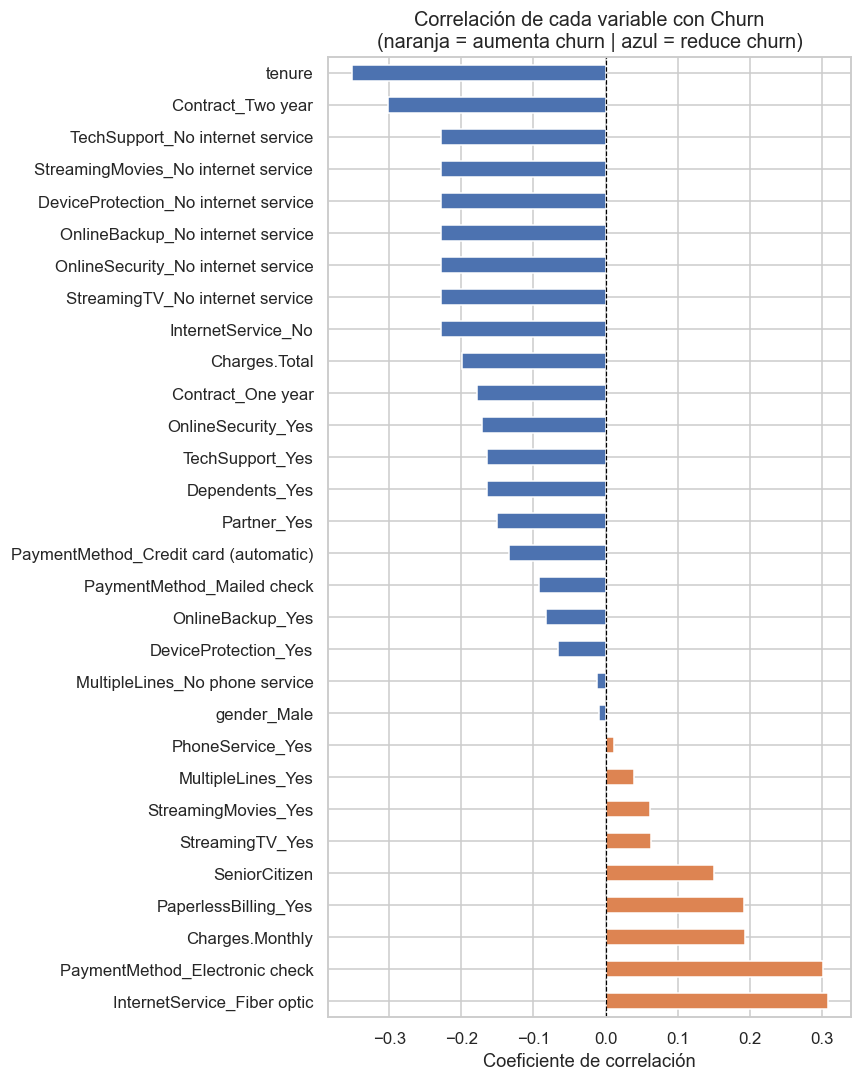

InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
Charges.Monthly                          0.193356
PaperlessBilling_Yes                     0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService_Yes                         0.011942
gender_Male                             -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner_Yes                             -0.150448
Dependents_Yes                          -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226
Contract_One year                       -0.177820


In [20]:
# Matriz de correlación para detectar correlaciones fuertes entre variables

churn_corr = (
    df_enc.corr(numeric_only=True)['Churn']
    .drop('Churn')
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 10))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in churn_corr.values]

churn_corr.plot(kind='barh', color=colors, edgecolor='white', ax=ax)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Correlación de cada variable con Churn\n(naranja = aumenta churn | azul = reduce churn)', fontsize=13)
ax.set_xlabel('Coeficiente de correlación')
plt.tight_layout()
plt.show()

print(churn_corr.to_string())

C:\Users\david\AppData\Local\Temp\ipykernel_40848\1742864292.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


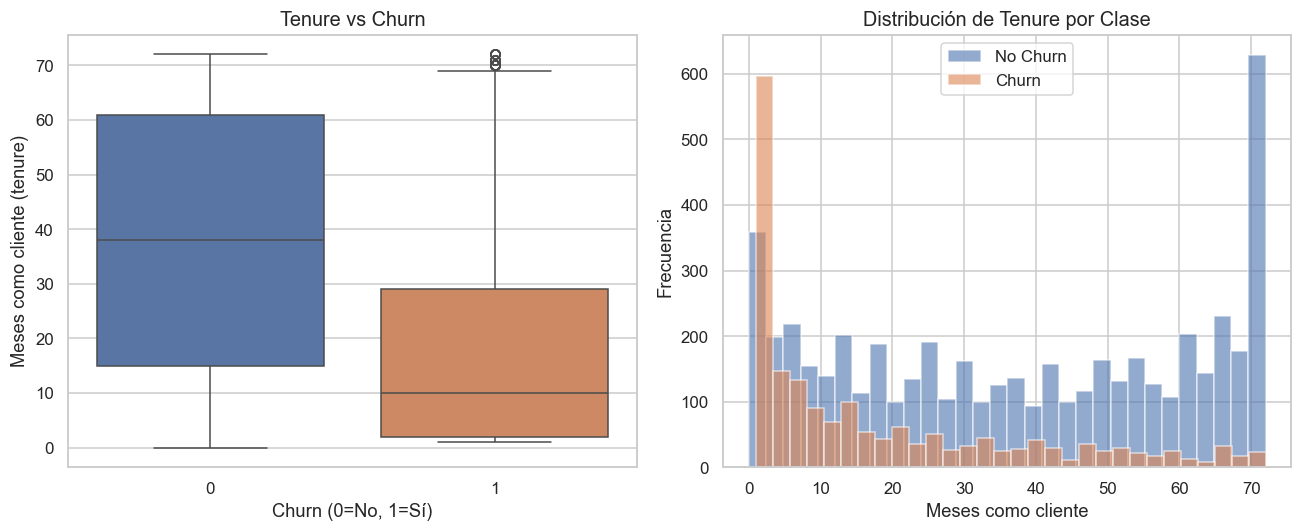

In [26]:
# Según se ha visto en la matriz de correlación, los clientes con mayor tiempo de permanecia
# son los que impactan menos en el churn, sin embargo, tambien se debe tomar en cuenta 
# el servicio de fibra optica ya que es el que impacta mas en el churn

#### Tenure

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    data=df_enc, x='Churn', y='tenure',
    palette=['#4C72B0', '#DD8452'],
    ax=axes[0]
)
axes[0].set_title('Tenure vs Churn', fontsize=13)
axes[0].set_xlabel('Churn (0=No, 1=Sí)')
axes[0].set_ylabel('Meses como cliente (tenure)')

# Distribución
for churn_val, color, label in [(0, '#4C72B0', 'No Churn'), (1, '#DD8452', 'Churn')]:
    subset = df_enc[df_enc['Churn'] == churn_val]['tenure']
    axes[1].hist(subset, bins=30, alpha=0.6, color=color, label=label, edgecolor='white')
axes[1].set_title('Distribución de Tenure por Clase', fontsize=13)
axes[1].set_xlabel('Meses como cliente')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

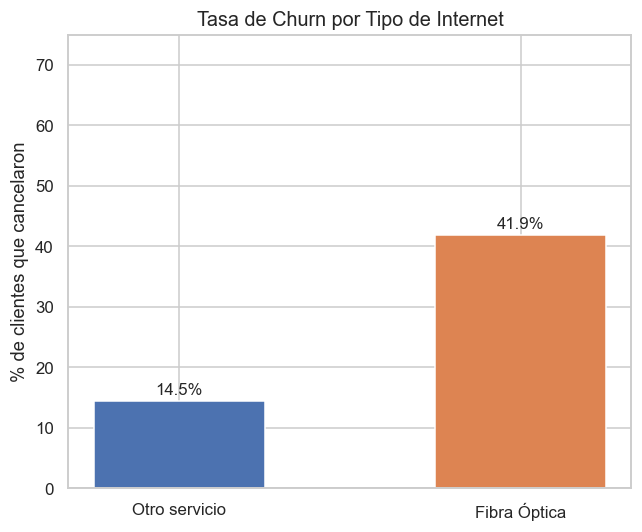

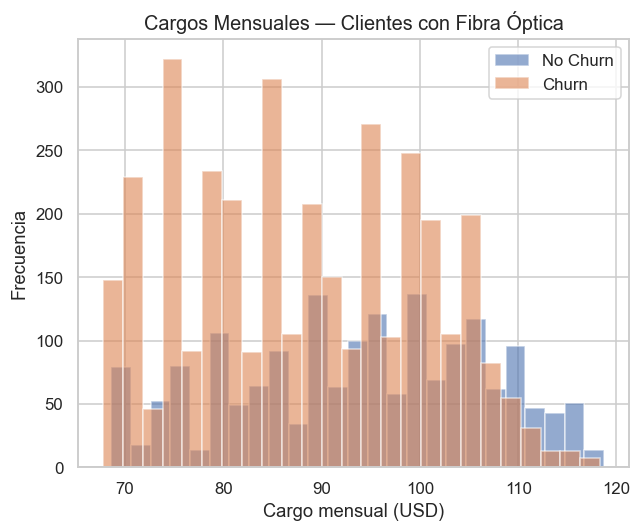

Tasa de churn — Fibra óptica:   0.664
Tasa de churn — Otro servicio:  0.324


In [39]:
### InternetService_Fiber optic

%matplotlib inline

#  Gráfico 1: Tasa de churn por tipo de internet 
tasa_otro  = df_enc[df_enc['InternetService_Fiber optic']==0]['Churn'].mean() * 100
tasa_fibra = df_enc[df_enc['InternetService_Fiber optic']==1]['Churn'].mean() * 100

fig1, ax1 = plt.subplots(figsize=(6, 5))
ax1.bar(['Otro servicio', 'Fibra Óptica'],
        [tasa_otro, tasa_fibra],
        color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
ax1.set_title('Tasa de Churn por Tipo de Internet', fontsize=13)
ax1.set_ylabel('% de clientes que cancelaron')
ax1.set_ylim(0, 75)
ax1.text(0, tasa_otro + 1, f'{tasa_otro:.1f}%', ha='center', fontsize=11)
ax1.text(1, tasa_fibra + 1, f'{tasa_fibra:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

#  Gráfico 2: Cargos mensuales en clientes con fibra óptica 
fig2, ax2 = plt.subplots(figsize=(6, 5))
for churn_val, color, label in [(0, '#4C72B0', 'No Churn'), (1, '#DD8452', 'Churn')]:
    subset = df_balanced[
        (df_balanced['Churn'] == churn_val) &
        (df_balanced['InternetService_Fiber optic'] == 1)
    ]['Charges.Monthly']
    ax2.hist(subset, bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
ax2.set_title('Cargos Mensuales — Clientes con Fibra Óptica', fontsize=13)
ax2.set_xlabel('Cargo mensual (USD)')
ax2.set_ylabel('Frecuencia')
ax2.legend()
plt.tight_layout()
plt.show()

#  Métricas 
print('Tasa de churn — Fibra óptica:  ',
      df_balanced[df_balanced['InternetService_Fiber optic']==1]['Churn'].mean().round(3))
print('Tasa de churn — Otro servicio: ',
      df_balanced[df_balanced['InternetService_Fiber optic']==0]['Churn'].mean().round(3))